# **Decision Tree And Random Forest Classifier Models**

In [2]:
# 모듈 import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Data Review <a id = "1"></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/EuronData/drug200.csv.xls")
data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [12]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [14]:
data.corr(numeric_only=True)

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


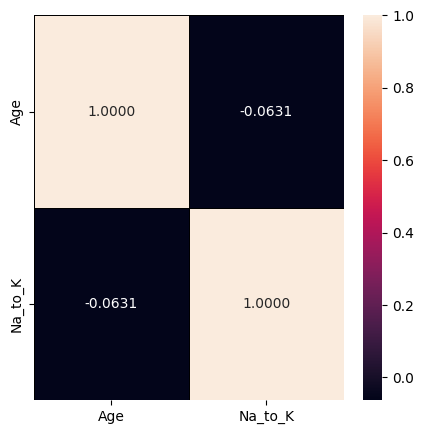

In [16]:
f, ax = plt.subplots(figsize = (5,5))
sns.heatmap(data.corr(numeric_only=True), annot = True, linewidths=0.5, linecolor = "black", fmt = ".4f", ax = ax)
plt.show()

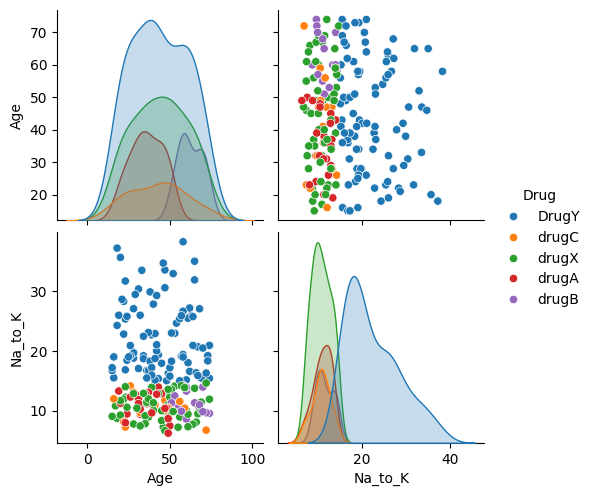

In [17]:
sns.pairplot(data, hue = "Drug")

In [18]:
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [19]:
data["Age"].value_counts(dropna=False)

,count
Age,
47,8
23,7
28,7
49,7
32,6
39,6
50,5
60,5
22,5


****

In [20]:
data["Sex"].value_counts()

,count
Sex,
M,104
F,96


****

In [21]:
data["BP"].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


****

In [22]:
data["Cholesterol"].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


****

In [23]:
data["Drug"].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


# Data Visualization <a id = "2"></a>

In [24]:
# Age visualization
dataAge = data["Age"].value_counts(dropna = False)
npar_dataAge = np.array(dataAge)
x = list(npar_dataAge)
y = data.Age.value_counts().index

DataAge = {"Age": y, "Number": x}
DataAge = pd.DataFrame(DataAge)

fig = px.bar(DataAge, x = "Age", y = "Number")
fig.show()

In [25]:
# Sex visualization
colors = ['gold', 'mediumturquoise']

fig = go.Figure(data = [go.Pie(labels= ['M', 'F'], values=[104, 96])])

fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value', textfont_size = 20,
                 marker = dict(colors = colors, line = dict( color = '#000000', width = 2)))

fig.show()

In [26]:
# BP visualization
fig = px.bar(x = ["HIGH", "LOW", "NORMAL"], y = [77, 64, 59])

fig.show()

In [27]:
# Cholestrol visualization
fig = px.histogram(x = ["HIGH", "NORMAL"], y = [103, 97])
fig.show()

In [28]:
# Drug visualization
fig = go.Figure(data = [go.Pie(labels=["DrugY","DrugX","DrugA","DrugC","DrugB"], values=[91,54,23,16,16])])

fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value', textfont_size = 20,
                 marker = dict(colors = px.colors.sequential.RdBu, line = dict( color = '#000000', width = 2)))

fig.show()

In [29]:
# Relationship between age and Na_To_K
fig = px.scatter(data, x = "Na_to_K", y="Age", color="Drug",
                 size='Age', hover_data=['Na_to_K'])
fig.show()

# Classifications Models <a id = "3"></a>

## Data Preparing <a id = "cm1"></a>

In [32]:
# dataset 다시 읽기
dataclass = pd.read_csv("/content/drive/MyDrive/EuronData/drug200.csv.xls")
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [33]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [34]:
# F = 1, M = 0로 sex data type 바꾸기
dataclass.Sex = [1 if i == "F" else 0 for i in dataclass.Sex]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,HIGH,HIGH,25.355,DrugY
1,47,0,LOW,HIGH,13.093,drugC
2,47,0,LOW,HIGH,10.114,drugC
3,28,1,NORMAL,HIGH,7.798,drugX
4,61,1,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,LOW,HIGH,11.567,drugC
196,16,0,LOW,HIGH,12.006,drugC
197,52,0,NORMAL,HIGH,9.894,drugX
198,23,0,NORMAL,NORMAL,14.020,drugX


In [36]:
# LOW = 2, NORMAL = 1, HIGH = 0 로 BP data type 바꾸기

import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass.BP)):
    if dataclass.BP[i] == "LOW":
        dataclass.BP[i] = 2

    elif dataclass.BP[i] == "NORMAL":
        dataclass.BP[i] = 1

    else:
        dataclass.BP[i] = 0

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,HIGH,25.355,DrugY
1,47,0,0,HIGH,13.093,drugC
2,47,0,0,HIGH,10.114,drugC
3,28,1,0,HIGH,7.798,drugX
4,61,1,0,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,0,HIGH,11.567,drugC
196,16,0,0,HIGH,12.006,drugC
197,52,0,0,HIGH,9.894,drugX
198,23,0,0,NORMAL,14.020,drugX


In [38]:
# HIGH = 1, NORMAL = 0로 cholestrol data type 바꾸기
dataclass.Cholesterol = [1 if i == "HIGH" else 0 for i in dataclass.Cholesterol]

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,0,25.355,DrugY
1,47,0,0,0,13.093,drugC
2,47,0,0,0,10.114,drugC
3,28,1,0,0,7.798,drugX
4,61,1,0,0,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,0,0,11.567,drugC
196,16,0,0,0,12.006,drugC
197,52,0,0,0,9.894,drugX
198,23,0,0,0,14.020,drugX


In [39]:
# DrugY = 4, DrugX = 3, DrugA = 2, DrugC = 1, DrugB = 0로 drug data type 바꾸기

import warnings
warnings.filterwarnings('ignore')

for i in range(0,len(dataclass)):
    if dataclass.Drug[i] == "DrugY":
        dataclass.Drug[i] = 4
    elif dataclass.Drug[i] == "drugX":
        dataclass.Drug[i] = 3
    elif dataclass.Drug[i] == "drugA":
        dataclass.Drug[i] = 2
    elif dataclass.Drug[i] == "drugC":
        dataclass.Drug[i] = 1
    else:
        dataclass.Drug[i] = 0

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,0,25.355,4
1,47,0,0,0,13.093,1
2,47,0,0,0,10.114,1
3,28,1,0,0,7.798,3
4,61,1,0,0,18.043,4
...,...,...,...,...,...,...
195,56,1,0,0,11.567,1
196,16,0,0,0,12.006,1
197,52,0,0,0,9.894,3
198,23,0,0,0,14.020,3


In [40]:
# 바뀐 dataset 확인
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [41]:
# integer type로 변환
data_types_dict = {'BP': int, "Drug": int}

dataclass = dataclass.astype(data_types_dict)

dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [42]:
x_data = dataclass.drop(["Drug"], axis = 1)

y_data = dataclass.Drug.values

In [43]:
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1,0,0,25.355
1,47,0,0,0,13.093
2,47,0,0,0,10.114
3,28,1,0,0,7.798
4,61,1,0,0,18.043
...,...,...,...,...,...
195,56,1,0,0,11.567
196,16,0,0,0,12.006
197,52,0,0,0,9.894
198,23,0,0,0,14.020


In [44]:
y_data

array([4, 1, 1, 3, 4, 3, 4, 1, 4, 4, 1, 4, 4, 4, 3, 4, 3, 2, 1, 4, 4, 4,
       4, 4, 4, 4, 4, 3, 4, 4, 3, 0, 3, 4, 3, 3, 2, 3, 3, 3, 4, 0, 4, 3,
       3, 3, 2, 1, 4, 4, 4, 3, 4, 4, 0, 1, 0, 4, 3, 4, 4, 2, 4, 3, 0, 4,
       2, 3, 4, 4, 0, 4, 3, 4, 4, 4, 2, 4, 2, 3, 0, 3, 1, 2, 1, 0, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 2, 2, 1, 3, 4, 3, 3, 4, 0, 4,
       2, 3, 3, 3, 3, 4, 3, 3, 2, 4, 4, 4, 4, 4, 0, 4, 4, 3, 4, 3, 4, 4,
       3, 4, 4, 3, 0, 2, 0, 3, 2, 4, 0, 4, 2, 3, 3, 2, 3, 1, 2, 0, 3, 3,
       4, 1, 2, 4, 1, 3, 3, 0, 3, 4, 4, 4, 4, 3, 4, 2, 3, 3, 4, 4, 2, 4,
       2, 4, 4, 4, 4, 3, 3, 4, 4, 4, 0, 2, 4, 4, 4, 2, 4, 1, 4, 1, 1, 3,
       3, 3])

In [45]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

## Decision Tree Classifier <a id = "cm2"></a>


In [83]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier()

# Fit
dtc.fit(x_train, y_train)

# Predict
predict = dtc.predict(x_test)

print('The accuracy of the Decision Tree is',metrics.accuracy_score(predict,y_test))

The accuracy of the Decision Tree is 0.6166666666666667


In [84]:
# criterion=gini
DTC_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)


# Fit
DTC_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [85]:
y_pred_gini = DTC_gini.predict(x_test)

In [86]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.5833


In [87]:
y_pred_train_gini = DTC_gini.predict(x_train)

y_pred_train_gini

array([3, 2, 2, 4, 2, 3, 3, 3, 4, 2, 3, 2, 4, 0, 4, 3, 4, 2, 4, 4, 4, 4,
       3, 4, 3, 4, 2, 2, 2, 3, 4, 2, 0, 3, 3, 3, 2, 2, 3, 4, 4, 4, 4, 3,
       2, 3, 0, 3, 4, 3, 4, 2, 4, 4, 2, 0, 4, 4, 2, 4, 4, 4, 2, 2, 4, 4,
       4, 3, 4, 2, 2, 2, 2, 2, 4, 4, 4, 4, 2, 4, 3, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 2, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 2, 4,
       4, 2, 3, 2, 2, 4, 2, 4, 4, 4, 0, 4, 2, 3, 2, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 2, 4, 2, 2, 3, 2])

In [88]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.7571


In [89]:
print('Training set score: {:.4f}'.format(DTC_gini.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_gini.score(x_test, y_test)))

Training set score: 0.7571
Test set score: 0.5833


In [90]:
# criterion=entropy
DTC_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


# Fit
DTC_en.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [91]:
y_pred_en = DTC_en.predict(x_test)

In [92]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.5833


In [93]:
y_pred_train_en = DTC_en.predict(x_train)

y_pred_train_en

array([3, 2, 2, 4, 2, 3, 3, 3, 4, 2, 3, 2, 4, 0, 4, 3, 4, 2, 4, 4, 4, 4,
       3, 4, 3, 4, 2, 2, 2, 3, 4, 2, 0, 3, 3, 3, 2, 2, 3, 4, 4, 4, 4, 3,
       2, 3, 0, 3, 4, 3, 4, 2, 4, 4, 2, 0, 4, 4, 2, 4, 4, 4, 2, 2, 4, 4,
       4, 3, 4, 2, 2, 2, 2, 2, 4, 4, 4, 4, 2, 4, 3, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 2, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 2, 4,
       4, 2, 3, 2, 2, 4, 2, 4, 4, 4, 0, 4, 2, 3, 2, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 2, 4, 2, 2, 3, 2])

In [94]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.7571


In [95]:
print('Training set score: {:.4f}'.format(DTC_en.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(DTC_en.score(x_test, y_test)))

Training set score: 0.7571
Test set score: 0.5833


## Random Forest Classifier <a id = "cm3"></a>

In [96]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state = 0)

# Fit
rfc.fit(x_train, y_train)

# Predict
predict = rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 0.6


In [97]:
# n_estimators=100
from sklearn.ensemble import RandomForestClassifier

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

# Fit
rfc_100.fit(x_train, y_train)

# Predict
predict = rfc_100.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 0.6


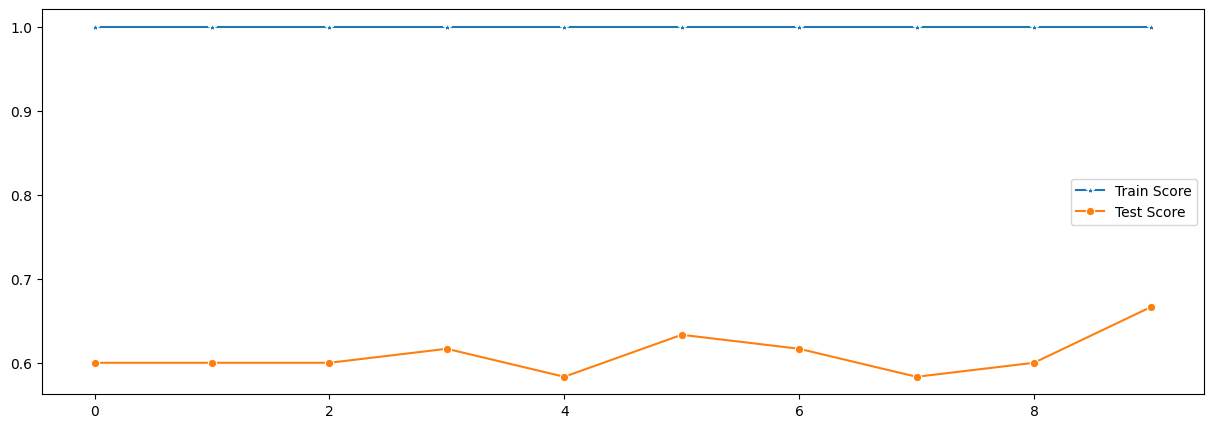

In [98]:
# best random_state value 찾기
test_score_list = []
train_score_list = []

for i in range(0,10):
    rfc2 = RandomForestClassifier(random_state=i)
    rfc2.fit(x_train, y_train)
    test_score_list.append(rfc2.score(x_test, y_test))
    train_score_list.append(rfc2.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,10), y=train_score_list, marker='*', label='Train Score')
p = sns.lineplot(x=range(0,10), y=test_score_list, marker='o', label='Test Score')

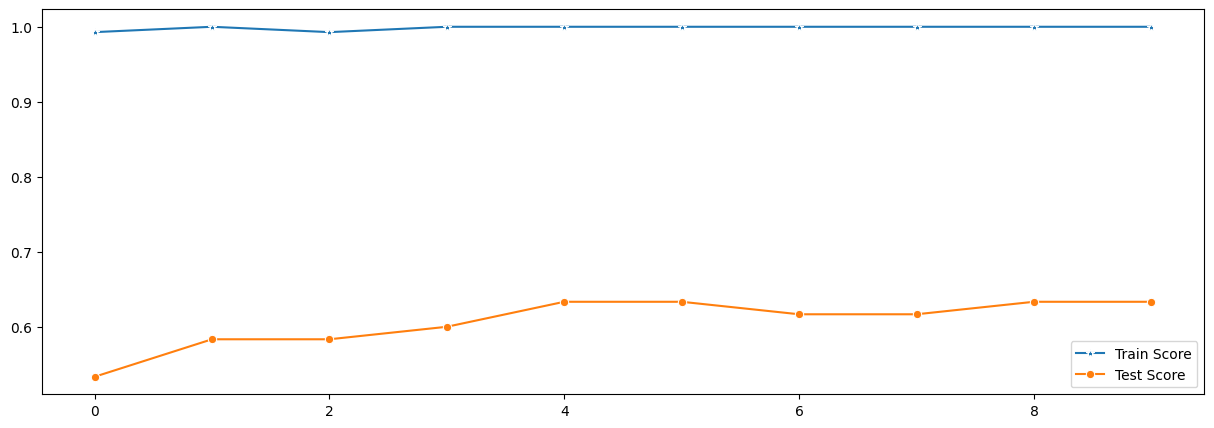

In [99]:
# best random_stete value = 5. best n_estimators parameter 찾기
test_score_list = []
train_score_list = []

list_n_estimators = [10,20,30,40,50,60,70,80,90,100]


for i in range(0,len(list_n_estimators)):
    rfc3 = RandomForestClassifier(n_estimators=list_n_estimators[i], random_state=5)
    rfc3.fit(x_train, y_train)
    test_score_list.append(rfc3.score(x_test, y_test))
    train_score_list.append(rfc3.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,len(list_n_estimators)),y=train_score_list,marker='*',label='Train Score')
p = sns.lineplot(x=range(0,len(list_n_estimators)),y=test_score_list,marker='o',label='Test Score')

In [100]:
last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# Fit
last_rfc.fit(x_train,y_train)

predict = last_rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(predict,y_test))

The accuracy of the Random Forest is 0.6333333333333333


In [101]:
y_pred_en = last_rfc.predict(x_test)

In [102]:
print('Model accuracy score with best parameters: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with best parameters: 0.6333


In [103]:
y_pred_train_en = last_rfc.predict(x_train)

y_pred_train_en

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 1, 4, 1, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 1, 3, 2, 3, 4, 2, 0, 0, 3, 3, 1, 3, 3, 4, 4, 4, 4, 3,
       1, 0, 0, 2, 4, 3, 4, 1, 4, 4, 1, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 1, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 1, 4, 4, 3, 4, 4, 4, 4, 4, 4, 1, 4,
       4, 2, 3, 1, 1, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [104]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [105]:
print('Training set score: {:.4f}'.format(last_rfc.score(x_train, y_train)))

print('Test set score: {:.4f}'.format(last_rfc.score(x_test, y_test)))

Training set score: 1.0000
Test set score: 0.6333


## Evaluation Classification Models <a id = "cm4"></a>

### Confusion Matrix <a id = "cm4-1"></a>

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()

# Fit
cm_des.fit(x_train,y_train)

y_pred_cm = cm_des.predict(x_test)
y_true = y_test

cm_des1 = confusion_matrix( y_true, y_pred_cm)
cm_des1

array([[ 0,  1,  0,  5,  0],
       [ 1,  0,  1,  2,  0],
       [ 0,  0,  3,  1,  0],
       [ 3,  5,  4,  7,  0],
       [ 0,  0,  0,  0, 27]])

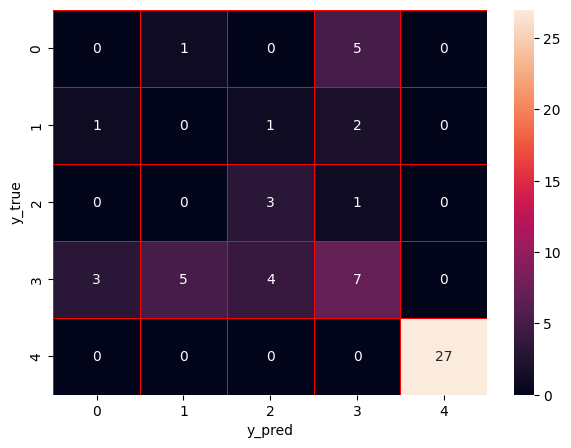

In [107]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des1, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [108]:
cm_des_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# Fit
cm_des_gini.fit(x_train,y_train)

y_pred_cm = cm_des_gini.predict(x_test)
y_true = y_test

cm_des2 = confusion_matrix( y_true, y_pred_cm)
cm_des2

array([[ 0,  0,  3,  3,  0],
       [ 0,  0,  1,  3,  0],
       [ 0,  0,  3,  1,  0],
       [ 2,  0, 12,  5,  0],
       [ 0,  0,  0,  0, 27]])

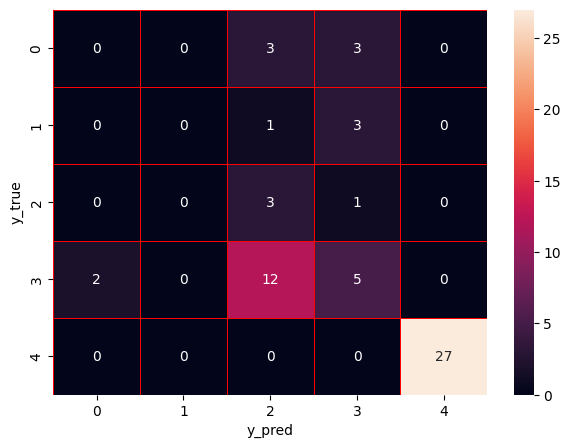

In [109]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [110]:
cm_last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# Fit
cm_last_rfc.fit(x_train, y_train)

y_pred_cm = cm_last_rfc.predict(x_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true, y_pred_cm)
cm_rfc

array([[ 2,  2,  0,  2,  0],
       [ 1,  0,  2,  1,  0],
       [ 0,  1,  2,  1,  0],
       [ 4,  5,  3,  7,  0],
       [ 0,  0,  0,  0, 27]])

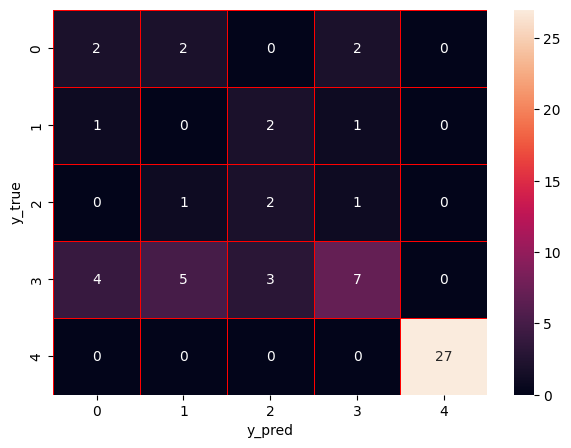

In [111]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc, annot = True, linewidths=0.5, linecolor="red", fmt = ".0f", ax = ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()